#Import Libraries

In [ ]:
# import libraries
import math, copy
import numpy as np
import matplotlib.pyplot as plt

#Convert Training Data to dimensional arrays

In [ ]:
# training datas X (Weather Temperature in Celsius). Y (Ice cream sales in units),
X = [20, 22, 25, 28, 30, 32, 35, 38]
Y = [100, 110, 125, 140, 150, 160, 175, 190]

# converting it to 1D array
x_train = np.array(X)
y_train = np.array(Y)

print(f'X Train = {x_train}')
print(f'Y Train = {y_train}')

X Train = [20 22 25 28 30 32 35 38]
Y Train = [100 110 125 140 150 160 175 190]


In [ ]:
# check no. of training examples
m = x_train.shape[0]
print(f'Number of Training examples : {m}')

Number of Training examples : 8


In [ ]:
# 'i'th place of x and y --> x_i and y_i (denotation)
for i in range(m):
  x_i = x_train[i]
  y_i = y_train[i]
  print(f'(x^{i},y^{i}) = ({x_i}, {y_i})')

(x^0,y^0) = (20, 100)
(x^1,y^1) = (22, 110)
(x^2,y^2) = (25, 125)
(x^3,y^3) = (28, 140)
(x^4,y^4) = (30, 150)
(x^5,y^5) = (32, 160)
(x^6,y^6) = (35, 175)
(x^7,y^7) = (38, 190)


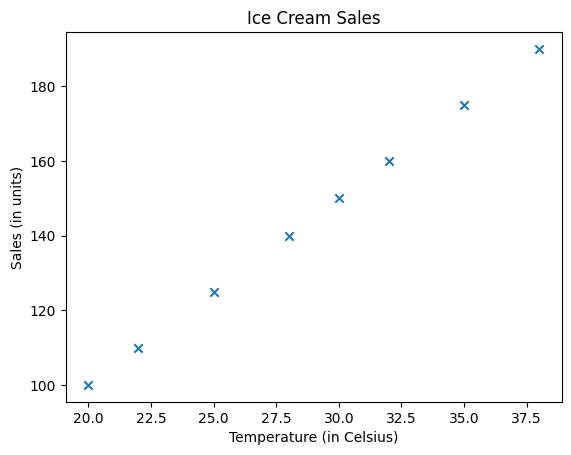

In [ ]:
# plot the given data
plt.scatter(x_train, y_train, marker='x')
# set the title
plt.title("Ice Cream Sales")
# set the x-axis label
plt.ylabel("Sales (in units)")
# set the y-axis label
plt.xlabel("Temperature (in Celsius)")

plt.show()

# Training Model

###Calculate cost function
Cost Function: A measure of how accurate the model with the training data


In [ ]:
# function to calculate cost
def compute_cost(x, y, w, b):
  cost = 0
  for i in range(m):
    f_wb = w * x[i] + b
    cost = cost + (f_wb - y[i])**2
  total_cost = 1 / (2 * m) * cost
  return total_cost

###Calculate Gradient values

In [ ]:
# function to calculate gradient
def compute_gradient(x, y, w, b):
  dj_dw = 0
  dj_db = 0

  for i in range(m):
    f_wb = w * x[i] + b
    dj_dw_i = (f_wb - y[i]) * x[i]
    dj_db_i = (f_wb - y[i])
    dj_dw += dj_dw_i
    dj_db += dj_db_i
  dj_dw /= m
  dj_db /= m
  return dj_dw, dj_db

### Calculate Gradient Descent

Gradient Descent: To get optimal value of parameters(w,b) of the cost function


In [ ]:
def gradient_descent(x, y, w_in, b_in, alpha, num_iters, cost_function, gradient_function):
  J_history = []
  p_history = []
  b = b_in
  w = w_in

  for i in range(num_iters):
    dj_dw, dj_db = compute_gradient(x, y, w, b)

    b = b - alpha * dj_db
    w = w - alpha * dj_dw

    if i<100000:      # prevent resource exhaustion
      J_history.append( cost_function(x, y, w , b))
      p_history.append([w,b])
        # Print cost every at intervals 10 times or as many iterations if < 10
      if i% math.ceil(num_iters/10) == 0:
        print(f"Iteration {i:4}: Cost {J_history[-1]:0.2e} ",
              f"dj_dw: {dj_dw: 0.3e}, dj_db: {dj_db: 0.3e}  ",
              f"w: {w: 0.3e}, b:{b: 0.5e}")

  return w, b, J_history, p_history

In [ ]:
w_init = 0
b_init = 0

iterations = 10000
tmp_alpha = 1.0e-3

w_final, b_final, J_hist, p_hist = gradient_descent(x_train ,y_train, w_init, b_init, tmp_alpha,
                                                    iterations, compute_cost, compute_gradient)
print(f"(w,b) found by gradient descent: ({w_final:8.4f},{b_final:8.4f})")

Iteration    0: Cost 2.06e+02  dj_dw: -4.304e+03, dj_db: -1.438e+02   w:  4.304e+00, b: 1.43750e-01
Iteration 1000: Cost 5.11e-04  dj_dw: -2.125e-04, dj_db:  6.361e-03   w:  4.995e+00, b: 1.60331e-01
Iteration 2000: Cost 4.72e-04  dj_dw: -2.042e-04, dj_db:  6.114e-03   w:  4.995e+00, b: 1.54095e-01
Iteration 3000: Cost 4.36e-04  dj_dw: -1.963e-04, dj_db:  5.876e-03   w:  4.995e+00, b: 1.48101e-01
Iteration 4000: Cost 4.02e-04  dj_dw: -1.886e-04, dj_db:  5.647e-03   w:  4.995e+00, b: 1.42340e-01
Iteration 5000: Cost 3.72e-04  dj_dw: -1.813e-04, dj_db:  5.428e-03   w:  4.995e+00, b: 1.36803e-01
Iteration 6000: Cost 3.43e-04  dj_dw: -1.742e-04, dj_db:  5.217e-03   w:  4.996e+00, b: 1.31482e-01
Iteration 7000: Cost 3.17e-04  dj_dw: -1.675e-04, dj_db:  5.014e-03   w:  4.996e+00, b: 1.26368e-01
Iteration 8000: Cost 2.93e-04  dj_dw: -1.610e-04, dj_db:  4.819e-03   w:  4.996e+00, b: 1.21452e-01
Iteration 9000: Cost 2.71e-04  dj_dw: -1.547e-04, dj_db:  4.631e-03   w:  4.996e+00, b: 1.16728e-01


#Model Prediction

In [ ]:
# for plotting the line
def compute_model_output(x, w, b):
  f_wb = np.zeros(m)
  for i in range(m):
    f_wb[i] = w * x[i] + b
  return f_wb
tmp_f_wb = compute_model_output(x_train, w_final, b_final)

In [ ]:
def prediction_output(x, w, b, x_train, y_train, tmp_f_wb):
  f_wb = w * x + b
  fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(12,4))
  ax1.plot(x_train, tmp_f_wb, c='b', label="our Prediction Line")
  ax1.scatter(x_train, y_train, marker = 'o', c='r', label = "Actual Values")
  # ax2.plot(x, f_wb, c='r', label="our Prediction Line")
  ax2.scatter(x, f_wb, marker = 'x', c='b', label = "Predicted Values")
  ax1.set_title("Ice Cream Sales (after model train)")
  ax2.set_title("Ice Cream Sales (Prediction)")
  ax1.set_ylabel("Sales (in units)")
  ax2.set_ylabel("Sales (in units)")
  ax1.set_xlabel("Temperature (in celsius)")
  ax2.set_xlabel("Temperature (in celsius)")
  plt.legend()
  plt.show()
  print(f"\n\nThe Predicted Ice cream Sales for {x} degree celsius is {f_wb:0.1f} units")

Give the Temperature value in celsius: 33.5


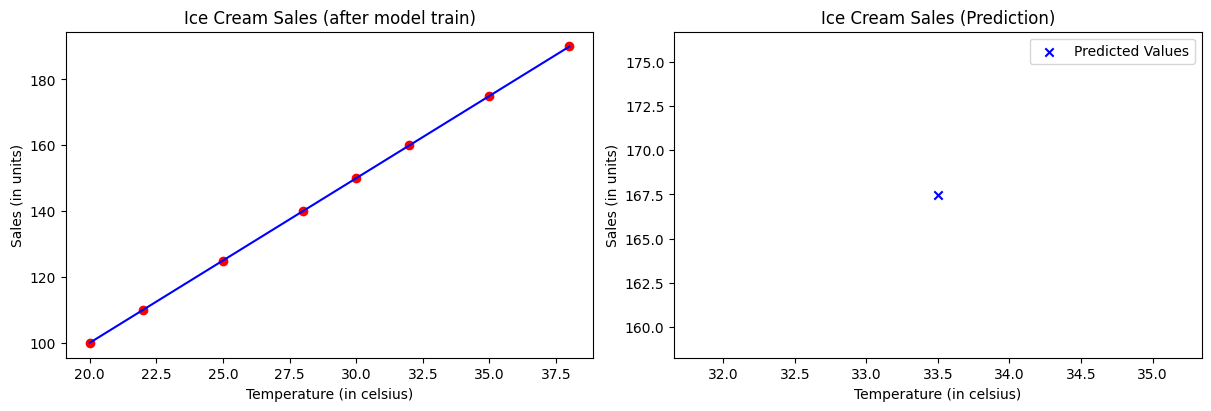



The Predicted Ice cream Sales for 33.5 degree celsius is 167.5 units


In [ ]:
Inp = float(input("Give the Temperature value in celsius: "))
prediction_output(Inp, w_final, b_final, x_train, y_train, tmp_f_wb)